# Pokemon DataSet Analysis

#### El objetivo de este trabajo es realizar un análisis exploratorio de datos a un DataSet completo sobre la información de los pokemons existentes hasta la séptima generación. Para comprender bien las características de los pokemons, se analizarán gran parte de los features que nos entrega el DataSet, esto con el proposito de determinar si dichas características definen, de manera general, el poder que posee cada pokemon.


#### El DataSet se compone de las siguientes características para más de 800 pokemons
- **name:** Nombre en inglés
- **japanese_name:** Nombre original en japonés
- **pokedex_number:** Número de pokemon en la pokedex
- **percentage_male:** Porcentaje de la especie que es masculina (nula si no tiene género)
- **type1:** Tipo principal del pokemon
- **type2:** Tipo secundario del pokemon
- **classification:** Especie descriptiva oficial del pokemon según la pokedex Sun/Moon
- **height_m:** Altura del pokemon en metros
- **weight_kg:** Peso del pokemon en kilogramos
- **capture_rate:** Ratio de captura del pokemon
- **base_egg_steps:** Número de pasos requerido para incubar un huevo
- **abilities:** Lista de habilidades que el pokemon puede tener
- **experience_growth:** Crecimiento de experimencia del pokemon
- **base_happiness:** Felicidad base del pokemon
- **against_?:** Dieciocho características que denotan la cantidad de daño recibido ante un ataque de un tipo determinado
- **hp:** Vida base del pokemon
- **attack:** Daño base del pokemon
- **defense:** Defensa base del pokemon
- **sp_attack:** Ataque especial base del pokemon
- **sp_defense:** Defensa especial base del pokemon
- **speed:** Velocidad base del pokemon
- **generation:** Generación en la que fue introducido el pokemon
- **is_legendary:** Denota si el pokemon es legendario

In [46]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pywaffle as Waffle
import squarify
import ast

In [2]:
PokemonSet = pd.read_csv('pokemon.csv', index_col=0)

PokemonSet

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
abilities,,,,,,,,,,,,,,,,,,,,,
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,2,80,80,60,grass,poison,13.0,1,0
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,3,122,120,80,grass,poison,100.0,1,0
"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,88.1,5,80,65,80,fire,NaN,19.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
['Beast Boost'],0.25,1.0,0.5,2.0,0.5,1.0,2.0,0.5,1.0,0.25,...,NaN,797,107,101,61,steel,flying,999.9,7,1
['Beast Boost'],1.00,1.0,0.5,0.5,0.5,2.0,4.0,1.0,1.0,0.25,...,NaN,798,59,31,109,grass,steel,0.1,7,1
['Beast Boost'],2.00,0.5,2.0,0.5,4.0,2.0,0.5,1.0,0.5,0.50,...,NaN,799,97,53,43,dark,dragon,888.0,7,1


### Verificación de complitud de data
**Nos aseguramos de que el dataset sea completo. En el caso de haber características con alta cantidad de NaN, nos debemos de asegurar de tenerlo en consideración para balancear nuestras fuentes de información y no asumir ideas erronéas con bases de datos incompletas.**

Del resultado observamos que la mayoría de características están completas. La falta de datos en *Percentage_male* corresponde a pokemones que no tienen género asignado, mientras que la falta en *type2* corresponden a pokemones de tipo único. Por otra parte observamos que hay en el conjunto 20 pokemones a los que no se les conoce su peso, y 20 a los que no se le conoce su altura.

In [3]:
datos_faltantes = PokemonSet.isnull().sum()
datos_faltantes1 = datos_faltantes[datos_faltantes>0]
datos_faltantes1


height_m            20
percentage_male     98
type2              384
weight_kg           20
dtype: int64

In [4]:
sin_altura_peso = PokemonSet[PokemonSet['height_m'].isnull() & PokemonSet['weight_kg'].isnull()]
sin_altura_peso[['name', 'height_m', 'weight_kg']].reset_index(drop=True)

,name,height_m,weight_kg
0,Rattata,NaN,NaN
1,Raticate,NaN,NaN
2,Raichu,NaN,NaN
3,Sandshrew,NaN,NaN
4,Sandslash,NaN,NaN
5,Vulpix,NaN,NaN
6,Ninetales,NaN,NaN
7,Diglett,NaN,NaN
8,Dugtrio,NaN,NaN
9,Meowth,NaN,NaN


/tmp/ipykernel_182879/2004411209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sin_altura_peso, x='generation', palette='Set2')


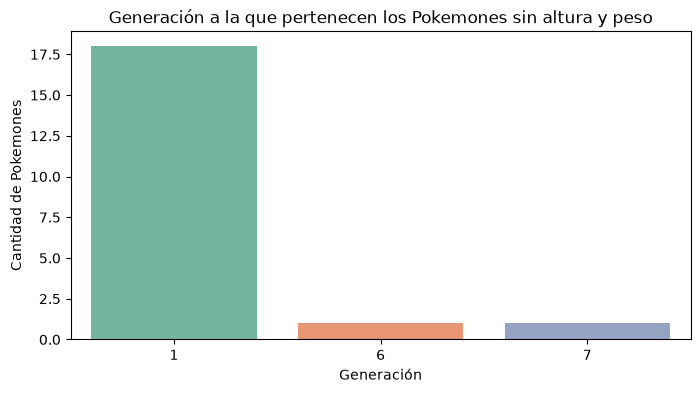

In [5]:
plt.figure(figsize=(8,4))

sns.countplot(data=sin_altura_peso, x='generation', palette='Set2')

plt.xlabel('Generación')
plt.ylabel('Cantidad de Pokemones')
plt.title('Generación a la que pertenecen los Pokemones sin altura y peso')

plt.show()

Del presente gráfico se comprueba que 18 de los pokemones a los que les falta información sobre su altura y peso pertenecen a la primera generación, mientras que 1 pertenece a la sexta y 1 a la séptima. A través de esta base de datos no fuimos capaces de demostrar la razón por la que estos pokemones carecen de información sobre sus masas y alturas. Sin embargo, a través de un análisis personal (y ñoño) se observó que los 18 pokemones pertenecientes a la primera generación corresponden a pokemones que poseen variación Alola, mientras que los pokemones de sexta y séptima generación de este grupo también poseen otras variaciones (distintas al Alola). Por lo que se deduce que este DataSet no incluye a las variaciones de pokemones en la pokedex, pero si indetermina estas dos características debido a que existen diferencias entre los originales y sus variaciones.

### Eliminación de data
**No todas las columnas de información en este dataset nos son de utilidad, así que eliminamos del conjunto a aquellas que no necesitamos. En este caso el conjunto eliminado es:**
1. **japanese_name:**
2. **pokedex_number:**
3. **base_egg_steps:**
4. **classification:**
5. **porcentage_male:**

In [6]:
PokemonSet.drop(['japanese_name', 'pokedex_number', 'base_egg_steps', 'classfication', 'percentage_male'], axis=1)

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,hp,name,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
abilities,,,,,,,,,,,,,,,,,,,,,
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,45,Bulbasaur,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,60,Ivysaur,80,80,60,grass,poison,13.0,1,0
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,80,Venusaur,122,120,80,grass,poison,100.0,1,0
"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,39,Charmander,60,50,65,fire,NaN,8.5,1,0
"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,58,Charmeleon,80,65,80,fire,NaN,19.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
['Beast Boost'],0.25,1.0,0.5,2.0,0.5,1.0,2.0,0.5,1.0,0.25,...,97,Celesteela,107,101,61,steel,flying,999.9,7,1
['Beast Boost'],1.00,1.0,0.5,0.5,0.5,2.0,4.0,1.0,1.0,0.25,...,59,Kartana,59,31,109,grass,steel,0.1,7,1
['Beast Boost'],2.00,0.5,2.0,0.5,4.0,2.0,0.5,1.0,0.5,0.50,...,223,Guzzlord,97,53,43,dark,dragon,888.0,7,1


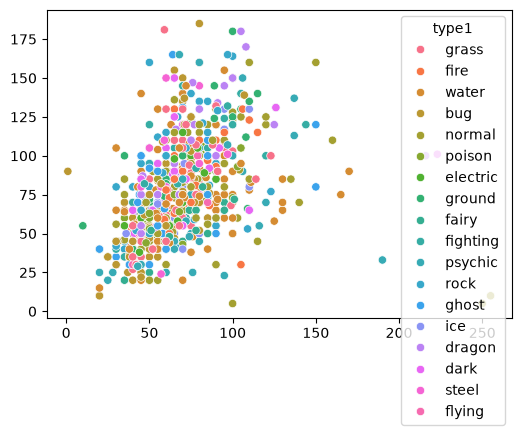

In [7]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=PokemonSet, x="hp", y="attack", hue="type1")

plt.xlabel("")
plt.ylabel("")
plt.title("")

plt.show()

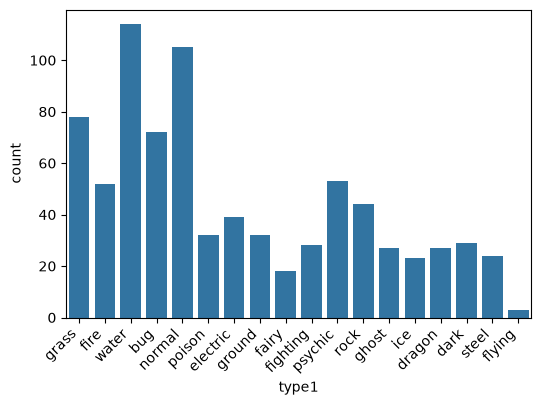

In [30]:
type1_count = PokemonSet['type1'].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(data=PokemonSet, x='type1')
plt.xticks(rotation=45, ha='right')

plt.show()

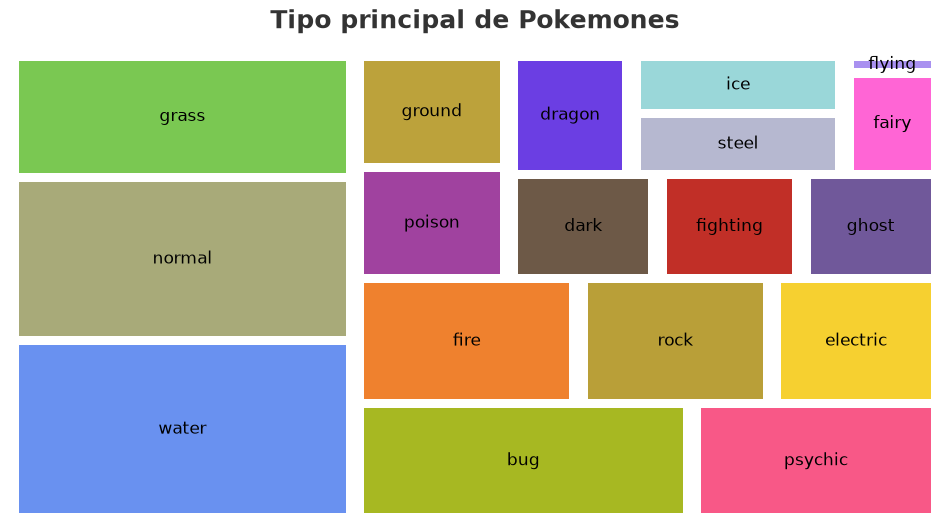

In [9]:
plt.figure(figsize=(12,6))

type1_values = PokemonSet['type1'].value_counts()


axis = squarify.plot(sizes=type1_values, label=type1_values.index, color=[
        '#6991F0',
        '#A8AA79',
        '#7AC852',
        '#A7B822',
        '#F85887',
        '#EF812E',
        '#B99F38',
        '#F6D030',
        '#A0429F',
        '#BCA23B',
        '#6D5947',
        '#C12F27',
        '#70589A',
        '#6B3EE3',
        '#B6B8D0',
        '#9AD7D9',
        '#FF65D5',
        '#A991F0',], pad=1, text_kwargs={'fontsize':12})

plt.axis("off")
axis.set_title("Tipo principal de Pokemones", fontsize=18, weight='bold', pad=20, color="#333333")

plt.show()

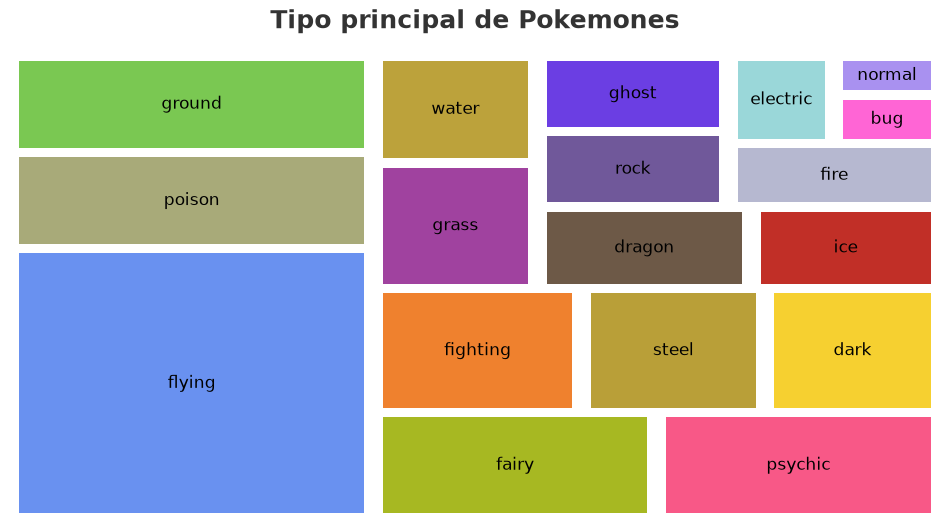

In [10]:
plt.figure(figsize=(12,6))

type1_values = PokemonSet['type2'].value_counts()


axis = squarify.plot(sizes=type1_values, label=type1_values.index, color=[
        '#6991F0',
        '#A8AA79',
        '#7AC852',
        '#A7B822',
        '#F85887',
        '#EF812E',
        '#B99F38',
        '#F6D030',
        '#A0429F',
        '#BCA23B',
        '#6D5947',
        '#C12F27',
        '#70589A',
        '#6B3EE3',
        '#B6B8D0',
        '#9AD7D9',
        '#FF65D5',
        '#A991F0',], pad=1, text_kwargs={'fontsize':12})

plt.axis("off")
axis.set_title("Tipo principal de Pokemones", fontsize=18, weight='bold', pad=20, color="#333333")

plt.show()

In [11]:
PokemonSet['type_combo'] = np.where(
    PokemonSet['type2'].isna(),
    PokemonSet['type1'],
    PokemonSet['type1'] + '/' + PokemonSet['type2']
)
PokemonSet['type_combo'].value_counts().head(10)

type_combo
water            61
normal           61
grass            37
psychic          35
fire             27
normal/flying    26
electric         26
fighting         22
bug              18
fairy            16
Name: count, dtype: int64

In [12]:
Capture_rate = PokemonSet['capture_rate'].value_counts()
Capture_rate

capture_rate
45                          250
190                          75
255                          69
75                           61
3                            58
120                          55
60                           50
90                           38
30                           20
200                          19
225                          15
25                           13
180                          11
235                           7
150                           7
50                            7
100                           6
140                           6
127                           5
70                            4
65                            3
125                           3
55                            3
170                           2
130                           2
15                            2
220                           2
80                            2
35                            1
205                           1
155                        

In [13]:
PokemonSet['capture_rate'] = pd.to_numeric(PokemonSet['capture_rate'], errors='coerce')
PokemonSet = PokemonSet.dropna(subset=['capture_rate', 'attack'])

In [14]:
LegendarySet = PokemonSet[PokemonSet['is_legendary'] == True]
top_tipos = LegendarySet['type_combo'].value_counts().nlargest(9).index
LegendarySet = LegendarySet.reset_index(drop=True)

/tmp/ipykernel_182879/700631933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=LegendarySet, y='type_combo', order=top_tipos, palette='Set2')


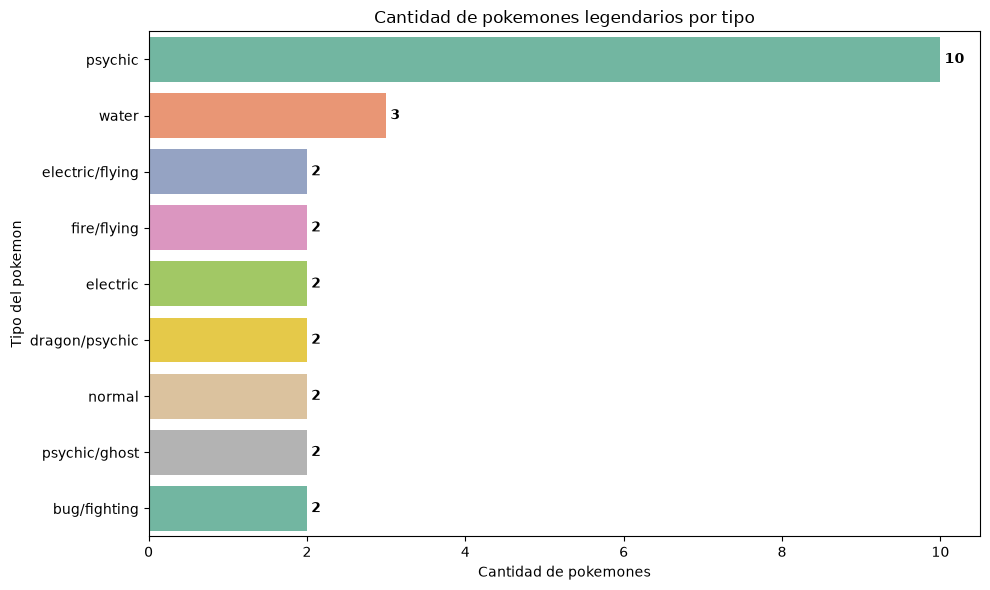

En total hay 70 Pokemones legendarios


In [15]:
plt.figure(figsize=(10,6))

ax = sns.countplot(data=LegendarySet, y='type_combo', order=top_tipos, palette='Set2')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')
    
plt.xlabel('Cantidad de pokemones')
plt.ylabel('Tipo del pokemon')
plt.title('Cantidad de pokemones legendarios por tipo')

plt.tight_layout()
plt.show()

print('En total hay', len(LegendarySet), 'Pokemones legendarios')

/tmp/ipykernel_182879/577492986.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_habilidades.values, y=top_habilidades.index, palette='viridis')


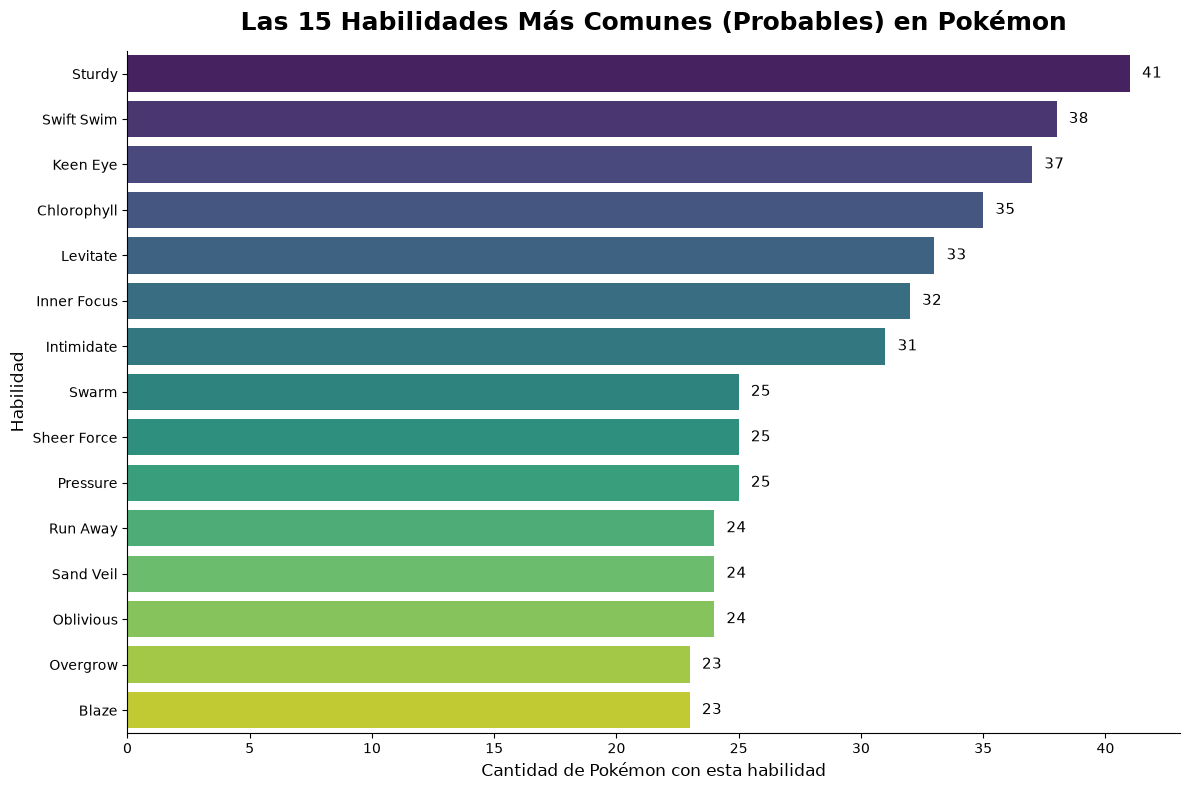

In [47]:
if 'abilities' in PokemonSet.columns:
    abilities_source = PokemonSet['abilities'].to_numpy()
else:
    abilities_source = PokemonSet.index.to_numpy()

def parse_abilities(value):
    if isinstance(value, list):
        return value
    if value is None or pd.isna(value):
        return []
    return ast.literal_eval(value)

PokemonSet['abilities_clean'] = [
    parse_abilities(value) for value in abilities_source
]

# 2. Desempaquetar las listas (una fila por cada habilidad que tenga el Pokémon)
habilidades_separadas = PokemonSet.explode('abilities_clean')

# 3. Contar las frecuencias y obtener el Top 15
top_habilidades = habilidades_separadas['abilities_clean'].value_counts().head(15)

# 4. Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 8))
sns.barplot(x=top_habilidades.values, y=top_habilidades.index, palette='viridis')

# Estilos y etiquetas
plt.title("Las 15 Habilidades Más Comunes (Probables) en Pokémon", fontsize=18, weight='bold', pad=15)
plt.xlabel("Cantidad de Pokémon con esta habilidad", fontsize=12)
plt.ylabel("Habilidad", fontsize=12)

# Añadir los números exactos al lado de cada barra
for index, value in enumerate(top_habilidades.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=11)

# Eliminar los bordes superior y derecho para un look más limpio
sns.despine()

plt.tight_layout()
plt.show()

In [53]:
colores_tipos = {
    'water': '#6991F0',     # Azul
    'normal': '#A8AA79',    # Grisáceo/Beige
    'grass': '#7AC852',     # Verde
    'bug': '#A7B822',       # Verde Amarillento
    'fairy': '#F85887',     # Rosa claro
    'fire': '#EF812E',      # Naranja/Rojo
    'rock': '#B99F38',      # Marrón amarillento
    'electric': '#F6D030',  # Amarillo
    'poison': '#A0429F',    # Morado
    'ground': '#BCA23B',    # Tierra/Arena
    'dark': '#6D5947',      # Marrón oscuro
    'fighting': '#C12F27',  # Rojo oscuro
    'ghost': '#70589A',     # Morado oscuro
    'dragon': '#6B3EE3',    # Índigo/Violeta
    'steel': '#B6B8D0',     # Gris metálico
    'ice': '#9AD7D9',       # Celeste/Hielo
    'psychic': '#FF65D5',   # Rosa brillante
    'flying': '#A991F0'     # Morado claro/Volador
}

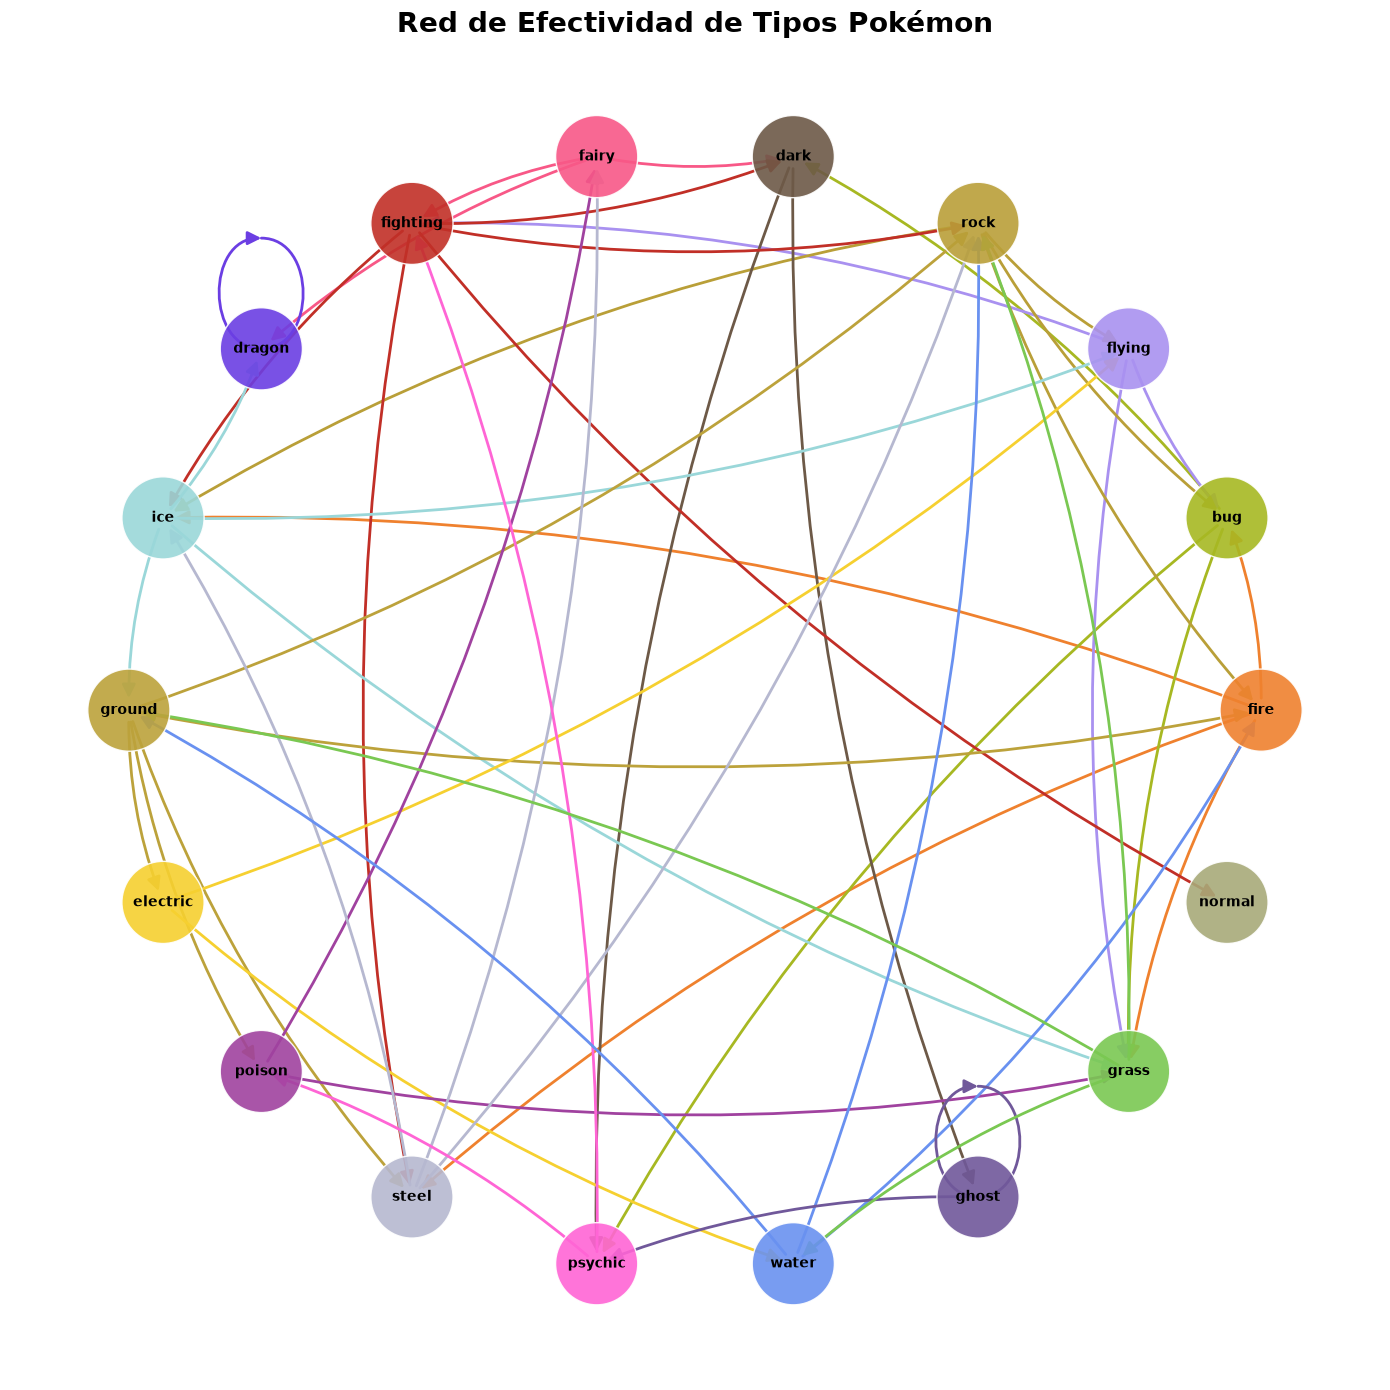

In [59]:
import networkx as nx
import matplotlib.pyplot as plt

conexiones = []
for tipo_defensor in efectividad.index:
    for col in columnas_contra:
        tipo_atacante = col.replace('against_', '')
        
        if tipo_atacante == 'fight':
            tipo_atacante = 'fighting'
            
        if efectividad.loc[tipo_defensor, col] > 1.1: 
            conexiones.append((tipo_atacante, tipo_defensor))

G = nx.DiGraph()
G.add_edges_from(conexiones)

colores_nodos = [colores_tipos[nodo] for nodo in G.nodes()]

colores_flechas = [colores_tipos[origen] for origen, destino in G.edges()]

plt.figure(figsize=(14, 14))
posiciones = nx.circular_layout(G)

nx.draw_networkx_nodes(G, posiciones, node_size=3500, node_color=colores_nodos, alpha=0.9, edgecolors='white')
nx.draw_networkx_labels(G, posiciones, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, posiciones, 
                       edgelist=G.edges(), 
                       arrowstyle='-|>', 
                       arrowsize=20, 
                       edge_color=colores_flechas,
                       width=2.0, # ¡Aquí está el cambio clave!
                       connectionstyle='arc3,rad=0.1', 
                       alpha=1) 

plt.title("Red de Efectividad de Tipos Pokémon", fontsize=20, weight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

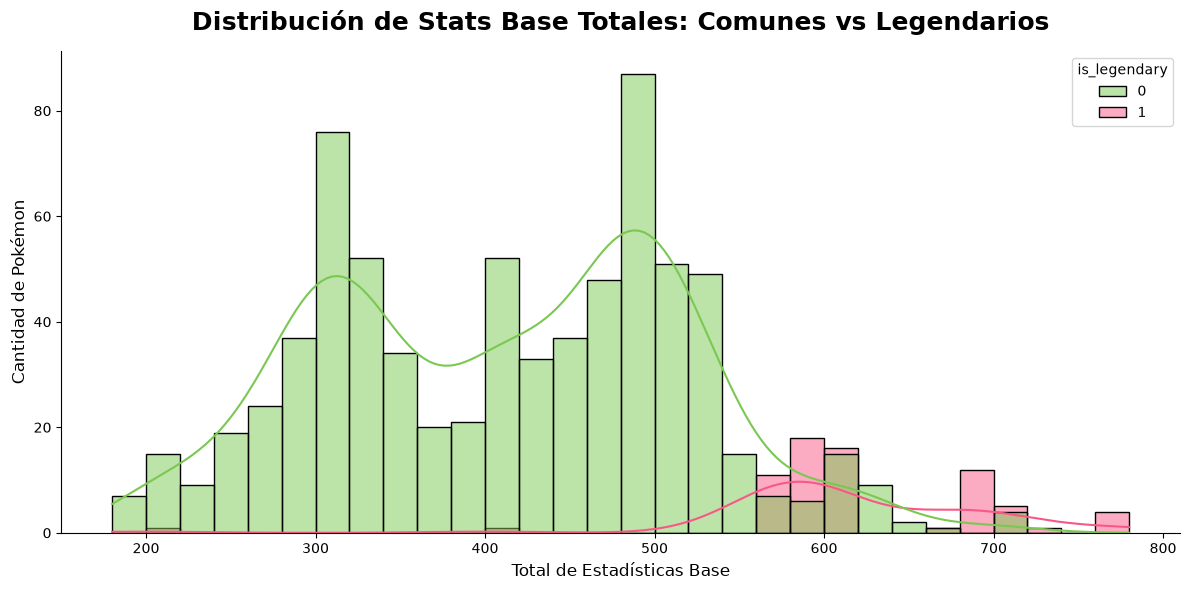

In [67]:
plt.figure(figsize=(12, 6))

# Creamos el histograma para la columna 'base_total'
# hue='is_legendary' separa los colores automáticamente
# kde=True dibuja la línea de tendencia suavizada
sns.histplot(data=PokemonSet, 
             x='base_total', 
             hue='is_legendary', 
             palette={0: '#7AC852', 1: '#F85887'}, # Verde (Comunes) y Rosa (Legendarios)
             kde=True, 
             bins=30, 
             alpha=0.5)

# Estilos y textos
plt.title("Distribución de Stats Base Totales: Comunes vs Legendarios", fontsize=18, weight='bold', pad=15)
plt.xlabel("Total de Estadísticas Base", fontsize=12)
plt.ylabel("Cantidad de Pokémon", fontsize=12)

# Desactivar bordes innecesarios para mayor limpieza
sns.despine()

plt.tight_layout()
plt.show()

In [78]:
pd.set_option('display.max_columns', None)
display(PokemonSet.nlargest(10, 'base_total'))

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary,type_combo,abilities_clean
abilities,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"['Pressure', 'Unnerve']",2.0,2.0,1.0,1.0,1.0,0.5,1.0,1.0,2.0,1.00,1.0,1.0,1.0,1.0,0.50,1.0,1.0,1.0,150,30720,0,780,3.0,Genetic Pokémon,70,1250000,2.0,106,Mewtwoミュウツー,Mewtwo,NaN,150,194,120,140,psychic,NaN,122.0,1,1,psychic,"[Pressure, Unnerve]"
['Air Lock'],0.5,1.0,2.0,1.0,2.0,0.5,0.5,1.0,1.0,0.25,0.0,4.0,1.0,1.0,1.00,2.0,1.0,0.5,180,30720,0,780,45.0,Sky High Pokémon,100,1250000,7.0,105,Rayquazaレックウザ,Rayquaza,NaN,384,180,100,115,dragon,flying,206.5,3,1,dragon/flying,[Air Lock]
['Drizzle'],1.0,1.0,1.0,2.0,1.0,1.0,0.5,1.0,1.0,2.00,1.0,0.5,1.0,1.0,1.00,1.0,0.5,0.5,150,30720,0,770,3.0,Sea Basin Pokémon,90,1250000,4.5,100,Kyogreカイオーガ,Kyogre,NaN,382,180,160,90,water,NaN,352.0,3,1,water,[Drizzle]
['Drought'],1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,2.00,1.0,2.0,1.0,0.5,1.00,0.5,1.0,2.0,180,30720,0,770,3.0,Continent Pokémon,160,1250000,3.5,100,Groudonグラードン,Groudon,NaN,383,150,90,90,ground,NaN,950.0,3,1,ground,[Drought]
['Multitype'],1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,0.0,1.00,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,120,30720,0,720,3.0,Alpha Pokémon,120,1250000,3.2,120,Arceusアルセウス,Arceus,NaN,493,120,120,120,normal,NaN,320.0,4,1,normal,[Multitype]
"['Aura Break', 'Power Construct']",1.0,1.0,2.0,0.0,2.0,1.0,0.5,1.0,1.0,1.00,1.0,4.0,1.0,0.5,1.00,0.5,1.0,1.0,100,30720,0,708,3.0,Order Pokémon,121,1250000,5.0,216,Zygarde (10% Forme)ジガルデ,Zygarde,NaN,718,91,95,85,dragon,ground,284.6,6,1,dragon/ground,"[Aura Break, Power Construct]"
"['Sand Stream', 'Unnerve']",2.0,0.5,1.0,1.0,2.0,4.0,0.5,0.5,0.5,2.00,2.0,1.0,0.5,0.5,0.00,1.0,2.0,2.0,164,10240,35,700,45.0,Armor Pokémon,150,1250000,2.0,100,Bangirasバンギラス,Tyranitar,50.0,248,95,120,71,rock,dark,202.0,2,0,rock/dark,"[Sand Stream, Unnerve]"
"['Intimidate', 'Moxie']",0.5,1.0,2.0,1.0,2.0,0.5,0.5,1.0,1.0,0.25,0.0,4.0,1.0,1.0,1.00,2.0,1.0,0.5,145,10240,35,700,45.0,Dragon Pokémon,130,1250000,1.5,95,Bohmanderボーマンダ,Salamence,50.0,373,120,90,120,dragon,flying,102.6,3,0,dragon/flying,"[Intimidate, Moxie]"
"['Clear Body', 'Light Metal']",1.0,2.0,0.5,1.0,0.5,1.0,2.0,0.5,2.0,0.50,2.0,0.5,0.5,0.0,0.25,0.5,0.5,1.0,145,10240,35,700,3.0,Iron Leg Pokémon,150,1250000,1.6,80,Metagrossメタグロス,Metagross,NaN,376,105,110,110,steel,psychic,550.0,3,0,steel/psychic,"[Clear Body, Light Metal]"


In [86]:
display(PokemonSet[PokemonSet["name"] == 'Mawile'])

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary,type_combo,abilities_clean
abilities,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"['Hyper Cutter', 'Intimidate', 'Sheer Force']",0.25,0.5,0.0,1.0,0.5,1.0,2.0,0.5,1.0,0.5,2.0,0.5,0.5,0.0,0.5,0.5,1.0,1.0,105,5120,70,480,45.0,Deceiver Pokémon,125,800000,0.6,50,Kucheatクチート,Mawile,50.0,303,55,95,50,steel,fairy,11.5,3,0,steel/fairy,"[Hyper Cutter, Intimidate, Sheer Force]"
